In [13]:
import pandas as pd 
import numpy as np

In [2]:
df = pd.read_csv("./performance.csv")
df.head()

,GENDER,TEAM,EDUCATION,TRAINING,ACHIEVEMENT,ABILITY,ATTITUDE
0,female,B,bachelor's degree,none,72,72,74
1,female,C,some college,completed,69,90,88
2,female,B,master's degree,none,90,95,93
3,male,A,associate's degree,none,47,57,44
4,male,C,some college,none,76,78,75


In [3]:
df['TEAM'].unique()

array(['B', 'C', 'A', 'D', 'E'], dtype=object)

#### 두 집단 평균 차이 검정  

In [4]:
df_a = df[df['TEAM'] == 'A']
df_b = df[df['TEAM'] == 'B']
df_c = df[df['TEAM'] == 'C']
df_d = df[df['TEAM'] == 'D']
df_e = df[df['TEAM'] == 'E']

In [6]:
# 검정을 할때는 series를 넣어줘야함 
df_a_ach = df_a['ACHIEVEMENT']
df_b_ach = df_b['ACHIEVEMENT']
df_c_ach = df_c['ACHIEVEMENT']
df_d_ach = df_d['ACHIEVEMENT']
df_e_ach = df_e['ACHIEVEMENT']

#### 정규성 검정 먼저 

In [9]:
import scipy as sp 

In [10]:
test_stat, p = sp.stats.shapiro(df_a_ach)
print("검정통계량: {}, p-value: {}".format(test_stat, p))  # 귀무가설을 기각할 수 없다. 정규분포를 따른다

검정통계량: 0.9917360440600248, p-value: 0.8545319451007725


In [11]:
test_stat, p = sp.stats.shapiro(df_b_ach)
print("검정통계량: {}, p-value: {}".format(test_stat, p))  # 귀무가설을 기각한다 (대립가설 채택). 정규분포를 따르지 않는다

검정통계량: 0.9808056990812756, p-value: 0.01038942653443885


#### z 검정 
- 위에 정규성검정 통과 못했지만 일단 그냥 돌려보기 

In [14]:
df_a_mean = np.mean(df_a_ach)
print(df_a_mean)

61.62921348314607


In [15]:
df_b_mean = np.mean(df_b_ach)
print(df_b_mean)

63.45263157894737


In [16]:
df_a_var = np.var(df_a_ach)
print(df_a_var)

208.54791061734628


In [17]:
df_b_var = np.var(df_b_ach)
print(df_b_var)

238.00565096952909


In [18]:
n1 = len(df_a_ach)
print(n1)

89


In [19]:
n2 = len(df_b_ach)
print(n2)

190


In [20]:
s = ((df_a_var/n1) + (df_b_var/n2))**0.5 
print(s)

1.8962848603648552


In [21]:
z_value = (df_b_mean - df_a_mean)/s
print(z_value)  # z통계량 (검정통계량)

0.9615739353898897


In [23]:
z_dist = sp.stats.norm(0, 1)
p_value = 1 - z_dist.cdf(z_value)
print(p_value)  # 귀무가설을 기각하지 않음. A, B 평균 성과 점수 차이가 없다  

0.16813183477339466


#### t-test  

In [25]:
test_stat, p = sp.stats.ttest_ind(df_b_ach, df_a_ach, alternative = 'greater')
print("검정통계량: {}, p-value: {}".format(test_stat, p))

검정통계량: 0.9355076279747488, p-value: 0.17517079808299785


#### 윌콕슨 순위합 검정  

In [26]:
test_stat, p = sp.stats.ranksums(df_b_ach, df_a_ach, alternative='greater')
print("검정통계량: {}, p-value: {}".format(test_stat, p)) 

검정통계량: 1.35398583683992, p-value: 0.08787044816326


## A집단과 C집단 평균 차이 검정 
- H0: 팀C의 평균 성과 점수와 팀A의 평균 성과 점수는 차이가 없다.
- H1: 팀C의 평균 성과 점수가 팀A의 평균 성과 점수보다 크다 

- 정규성 검정 

In [27]:
test_stat, p = sp.stats.shapiro(df_a_ach)
print("검정통계량: {}, p-value: {}".format(test_stat, p))  # 귀무가설을 기각할 수 없다. 정규분포를 따른다

검정통계량: 0.9917360440600248, p-value: 0.8545319451007725


In [28]:
test_stat, p = sp.stats.shapiro(df_c_ach)
print("검정통계량: {}, p-value: {}".format(test_stat, p))  # 귀무가설을 기각할 수 있다. 정규분포를 따르지 않는다

검정통계량: 0.9891068965131897, p-value: 0.017414767041862515


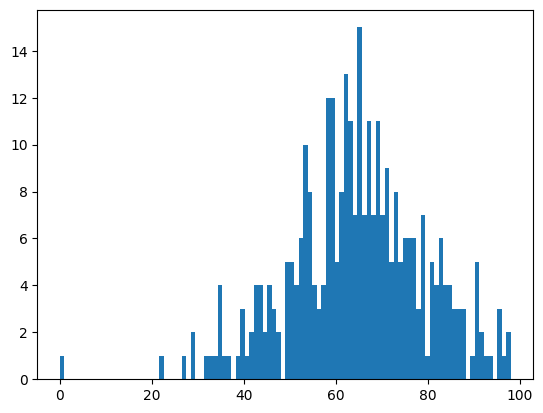

In [44]:
import matplotlib.pyplot as plt 
plt.hist(df_c_ach, bins=100)
plt.show()

- z test 

In [29]:
df_a_mean = np.mean(df_a_ach)
print(df_a_mean) 

61.62921348314607


In [30]:
df_c_mean = np.mean(df_c_ach)
print(df_c_mean)

64.46394984326018


In [31]:
df_a_var = np.var(df_a_ach)
print(df_a_var)

208.54791061734628


In [32]:
df_c_var = np.var(df_c_ach)
print(df_c_var)

219.9101423924686


In [33]:
n1 = len(df_a_ach)
n2 = len(df_c_ach)
print(n1)
print(n2)

89
319


In [34]:
s = ((df_a_var/n1) + (df_c_var/n2))**0.5
print(s)

1.741438611573898


In [35]:
z_value = (df_c_mean - df_a_mean)/s
print(z_value)

1.6278129709964926


In [36]:
z_dist = sp.stats.norm(0, 1)
p_value = 1 - z_dist.cdf(z_value)
print(p_value)  # 0.05보다 크므로 귀무가설 기각하지 않음 

0.05178227465937668


#### t-test 

In [37]:
test_stat, p = sp.stats.ttest_ind(df_c_ach, df_a_ach, alternative='greater')
print("검정통계량: {}, p-value: {}".format(test_stat, p)) 

검정통계량: 1.5997220303217299, p-value: 0.055219053727940205


In [39]:
test_stat, p = sp.stats.ttest_ind(df_a_ach, df_c_ach, alternative='less')
print("검정통계량: {}, p-value: {}".format(test_stat, p)) 

검정통계량: -1.5997220303217299, p-value: 0.055219053727940205


#### 윌콕슨 순위합 검정 

In [40]:
test_stat, p = sp.stats.ranksums(df_c_ach, df_a_ach, alternative='greater')
print("검정통계량: {}, p-value: {}".format(test_stat, p)) 

검정통계량: 1.9131906213930467, p-value: 0.027861826861397612


### 세 집단 평균 차이 검정 

#### 정규성 검정 - 샤피로 윌크 테스트  
- 일부 집단에서 정규성 검정 만족하지 않음 -> kruskal-wallis 로 넘어가기 가능 

In [45]:
test_stat, p = sp.stats.shapiro(df_a_ach)  
print("검정통계량: {}, p-value: {}".format(test_stat, p)) 

검정통계량: 0.9917360440600248, p-value: 0.8545319451007725


In [50]:
test_stat, p = sp.stats.shapiro(df_b_ach)  
print("검정통계량: {}, p-value: {}".format(test_stat, p)) 
print("귀무가설 기각. 정규분포를 따르지 않는다.")  

검정통계량: 0.9808056990812756, p-value: 0.01038942653443885
귀무가설 기각. 정규분포를 따르지 않는다.


In [51]:
test_stat, p = sp.stats.shapiro(df_c_ach)  
print("검정통계량: {}, p-value: {}".format(test_stat, p)) 
print("귀무가설 기각. 정규분포를 따르지 않는다.")

검정통계량: 0.9891068965131897, p-value: 0.017414767041862515
귀무가설 기각. 정규분포를 따르지 않는다.


In [48]:
test_stat, p = sp.stats.shapiro(df_d_ach)  
print("검정통계량: {}, p-value: {}".format(test_stat, p)) 

검정통계량: 0.9896670870859058, p-value: 0.059268293234778335


In [52]:
test_stat, p = sp.stats.shapiro(df_e_ach)  
print("검정통계량: {}, p-value: {}".format(test_stat, p))  
print("귀무가설 기각. 정규분포를 따르지 않는다.")  

검정통계량: 0.9770447788984441, p-value: 0.018493716885038675
귀무가설 기각. 정규분포를 따르지 않는다.


#### 분산 동질성 검정 

In [54]:
test_stat, p = sp.stats.bartlett(df_a_ach, df_b_ach, df_c_ach, df_d_ach, df_e_ach)
print("검정통계량: {}, p-value: {}".format(test_stat, p))  
print("귀무가설 기각할 수 없음. 분산이 동일하다")

검정통계량: 4.075678014368108, p-value: 0.39586081869788264
귀무가설 기각할 수 없음. 분산이 동일하다


### ANOVA 

In [58]:
test_stat, p_val = sp.stats.f_oneway(df_a_ach, df_b_ach, df_c_ach, df_d_ach, df_e_ach)  
print("검정통계량: {}, p-value: {}".format(test_stat, p_val))  
print("귀무가설 기각. 집단 간 평균에 차이가 있다.")

검정통계량: 14.593885166332635, p-value: 1.3732194030370688e-11
귀무가설 기각. 집단 간 평균에 차이가 있다.


#### Kruskal-Wallis 테스트 

In [59]:
test_stat, p_val = sp.stats.kruskal(df_a_ach, df_b_ach, df_c_ach, df_d_ach, df_e_ach)  
print("검정통계량: {}, p-value: {}".format(test_stat, p_val))  
print("귀무가설 기각. 집단 간 평균에 차이가 있다.") 

검정통계량: 57.079329705742886, p-value: 1.1906568165839682e-11
귀무가설 기각. 집단 간 평균에 차이가 있다.


### 카이제곱 검정 

In [60]:
df.head()

,GENDER,TEAM,EDUCATION,TRAINING,ACHIEVEMENT,ABILITY,ATTITUDE
0,female,B,bachelor's degree,none,72,72,74
1,female,C,some college,completed,69,90,88
2,female,B,master's degree,none,90,95,93
3,male,A,associate's degree,none,47,57,44
4,male,C,some college,none,76,78,75


In [61]:
df['C_OR_NOT'] = np.where(df['TEAM'] == 'C', 'C', 'not_C')
df.head()

,GENDER,TEAM,EDUCATION,TRAINING,ACHIEVEMENT,ABILITY,ATTITUDE,C_OR_NOT
0,female,B,bachelor's degree,none,72,72,74,not_C
1,female,C,some college,completed,69,90,88,C
2,female,B,master's degree,none,90,95,93,not_C
3,male,A,associate's degree,none,47,57,44,not_C
4,male,C,some college,none,76,78,75,C


In [62]:
df.TRAINING.unique()

array(['none', 'completed'], dtype=object)

In [63]:
df.C_OR_NOT.unique()

array(['not_C', 'C'], dtype=object)

In [64]:
obs = pd.crosstab(df['C_OR_NOT'], df['TRAINING'])
obs

TRAINING,completed,none
C_OR_NOT,,
C,117,202
not_C,241,440


In [69]:
chi2, p_value, d, expected = sp.stats.chi2_contingency(obs)
print("H0: 팀 C 여부와 사내교육 수강여부는 연관성이 없다.")
print("H1: 팀 C 여부와 사내교육 수강여부는 연관성이 있다.")
print("검정통계량: ", chi2) 
print("p-value: ", p_value) 
print("결론: H0 채택. 팀 C 여부와 사내교육 수강여부는 연관성이 없다.")

H0: 팀 C 여부와 사내교육 수강여부는 연관성이 없다.
H1: 팀 C 여부와 사내교육 수강여부는 연관성이 있다.
검정통계량:  0.10576554193252763
p-value:  0.745017489209715
결론: H0 채택. 팀 C 여부와 사내교육 수강여부는 연관성이 없다.
